# 01 — Exploratory Data Analysis

Structured exploratory review of the Ames Housing dataset.  
Covers: data loading, variable profiling, metadata parsing, missing-value inspection, and numerical/categorical quality reporting.

**Scope:** EDA only. No preprocessing, feature engineering, or modeling.

## 1. Imports

In [1]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import chi2_contingency, kurtosis, skew
from statsmodels.stats.outliers_influence import variance_inflation_factor

## 2. Data Loading

In [2]:
data_path = '../data/raw/AmesHousing.csv'
df = pd.read_csv(data_path)

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [3]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


## 3. Variable Profiling Table

Compact profiling table for all variables: completeness, cardinality, type, and descriptive summaries.

In [4]:
def summary_profiling_table(df: pd.DataFrame) -> pd.DataFrame:
    summary = []
    for col in df.columns:
        series = df[col]
        summary.append({
            "variable": col,
            "num_of_values": series.notna().sum(),
            "pct_missing": series.isna().mean() * 100,
            "unique_values": series.nunique(dropna=True),
            "mean": series.mean() if pd.api.types.is_numeric_dtype(series) else np.nan,
            "python_type": str(series.dtype),
            "inferred_type": pd.api.types.infer_dtype(series, skipna=True)
        })
    return (
        pd.DataFrame(summary)
        .sort_values(by=["pct_missing", "unique_values"], ascending=[False, False])
        .reset_index(drop=True)
    )

summary_profiling_table(df)

,variable,num_of_values,pct_missing,unique_values,mean,python_type,inferred_type
0,Pool QC,13,99.556314,4,NaN,str,string
1,Misc Feature,106,96.382253,5,NaN,str,string
2,Alley,198,93.242321,2,NaN,str,string
3,Fence,572,80.477816,4,NaN,str,string
4,Mas Vnr Type,1155,60.580205,4,NaN,str,string
...,...,...,...,...,...,...,...
77,Land Slope,2930,0.000000,3,NaN,str,string
78,Half Bath,2930,0.000000,3,0.379522,int64,integer
79,Paved Drive,2930,0.000000,3,NaN,str,string
80,Street,2930,0.000000,2,NaN,str,string


## 4. Metadata Loading and Parsing

Metadata file is parsed into a tabular structure for comparison with observed dataset fields.

In [5]:
def load_metadata_table(filepath: str) -> pd.DataFrame:
    """
    Parse Ames Housing metadata file and return a structured table
    with Variable Name, Variable Type, and Description.
    """
    variables = []
    pattern = re.compile(r"^(.+?)\s*\((Nominal|Ordinal|Discrete|Continuous)\):\s*(.+)")

    with open(filepath, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for line in lines:
        match = pattern.match(line.strip())
        if match:
            variables.append({
                "Variable": match.group(1).strip(),
                "Type": match.group(2).strip(),
                "Description": match.group(3).strip()
            })

    return pd.DataFrame(variables)

metadata_df = load_metadata_table("../metada.txt")
metadata_df

,Variable,Type,Description
0,Order,Discrete,Observation number
1,PID,Nominal,Parcel identification number - can be used wi...
2,MS SubClass,Nominal,Identifies the type of dwelling involved in th...
3,MS Zoning,Nominal,Identifies the general zoning classification o...
4,Lot Frontage,Continuous,Linear feet of street connected to property
...,...,...,...
75,Mo Sold,Discrete,Month Sold (MM)
76,Yr Sold,Discrete,Year Sold (YYYY)
77,Sale Type,Nominal,Type of sale
78,Sale Condition,Nominal,Condition of sale


## 5. Missing Values Overview

Identify columns with missing values ordered by frequency.

In [6]:
def missing_columns(df):
    """Return list of columns with missing values, ordered by count (descending)."""
    missing = df.isna().sum().sort_values(ascending=False)
    return missing[missing > 0].index.tolist()

missing = missing_columns(df)
print(f"{len(missing)} columns with missing values:")
print(missing)

27 columns with missing values:
['Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Mas Vnr Type', 'Fireplace Qu', 'Lot Frontage', 'Garage Qual', 'Garage Yr Blt', 'Garage Cond', 'Garage Finish', 'Garage Type', 'Bsmt Exposure', 'BsmtFin Type 2', 'Bsmt Qual', 'Bsmt Cond', 'BsmtFin Type 1', 'Mas Vnr Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Total Bsmt SF', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Garage Area', 'Garage Cars', 'Bsmt Unf SF', 'Electrical']


## 6. Detailed Inspection of Columns with Missing Values

Value frequencies and unique entries for each variable with missing observations.

In [7]:
for col in df.columns:
    if col in missing:
        print(f"\n===== {col} =====")
        print(df[col].value_counts(dropna=False))
        print(df[col].unique())


===== Lot Frontage =====
Lot Frontage
NaN      490
60.0     276
80.0     137
70.0     133
50.0     117
        ... 
168.0      1
111.0      1
131.0      1
153.0      1
133.0      1
Name: count, Length: 129, dtype: int64
[141.  80.  81.  93.  74.  78.  41.  43.  39.  60.  75.  nan  63.  85.
  47. 152.  88. 140. 105.  65.  70.  26.  21.  53.  24. 102.  98.  83.
  94.  95.  90.  79. 100.  44. 110.  61.  36.  67. 108.  59.  92.  58.
  56.  73.  72.  84.  76.  50.  55.  68. 107.  25.  30.  57.  40.  77.
 120. 137.  87. 119.  64.  96.  71.  69.  52.  51.  54.  86. 124.  82.
  38.  48.  89.  66.  45.  35. 129.  31.  42.  28.  99. 104.  97. 103.
  34. 117. 149. 122.  62. 174. 106. 112.  32. 115. 128.  91.  33. 121.
 144. 130. 109. 150. 113. 125. 101.  46. 114. 135. 136.  37.  22. 313.
  49. 123. 160. 195. 118. 134. 182. 116. 138. 155. 126. 200. 168. 111.
 131. 153. 133.]

===== Alley =====
Alley
NaN     2732
Grvl     120
Pave      78
Name: count, dtype: int64
<StringArray>
[nan, 'Pave', 'Grvl

## 7. Structural vs Non-Structural Missing Values

Separate missing values that are structurally justified by metadata from those without justification.

In [8]:
def extrair_variaveis_com_na(metadata_texto, df):
    """
    Returns two lists from variables with NaN in the dataset:
    - estrutural: NA justified by metadata (explicit) OR belonging to
                  Bsmt/Garage/MasVnr family (implicit)
    - nao_justificado: NaN without any metadata justification
    """
    variavel_pattern = re.compile(r'^([\w\s./-]+)\s*\([^\)]+\)\s*:', re.MULTILINE)
    na_pattern = re.compile(r'^\s*(NA|None)(\s|$)', re.MULTILINE)
    blocos = re.split(r'\n(?=\S[\w\s./-]*\s*\([^\)]+\)\s*:)', metadata_texto)

    na_explicito = [
        m.group(1).strip()
        for bloco in blocos
        for m in [variavel_pattern.match(bloco)]
        if m and na_pattern.search(bloco)
    ]

    familias = [r'(?i)bsmt', r'(?i)basement', r'(?i)garage', r'(?i)mas.?vnr']
    vars_com_nan = [col for col in df.columns if df[col].isna().any()]

    estrutural, nao_justificado = [], []
    for var in vars_com_nan:
        if var in na_explicito or any(re.search(p, var) for p in familias):
            estrutural.append(var)
        else:
            nao_justificado.append(var)

    return estrutural, nao_justificado


with open("../metada.txt", "r", encoding="utf-8") as f:
    metadata_texto = f.read()

estrutural, nao_justificado = extrair_variaveis_com_na(metadata_texto, df)
estrutural.append('Fireplace Qu')
nao_justificado.remove('Fireplace Qu')

print("Structural (justified):", estrutural)
print("Not justified:", nao_justificado)

Structural (justified): ['Alley', 'Mas Vnr Type', 'Mas Vnr Area', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 'Garage Cond', 'Pool QC', 'Fence', 'Misc Feature', 'Fireplace Qu']
Not justified: ['Lot Frontage', 'Electrical']


## 8. Targeted Assessment of MCAR Plausibility

Statistical procedure to examine whether selected missingness patterns are compatible with an MCAR assumption.

In [9]:
from scipy import stats


def test_mcar_targeted(df, target_var, candidate_predictors, verbose=True):
    """
    Tests MCAR for target_var using only theoretically motivated predictors.
    Returns dict with test results and interpretation.
    """
    df = df.copy()
    missing_indicator = df[target_var].isna().astype(int)
    n_missing = missing_indicator.sum()

    if n_missing < 10:
        return {
            "target": target_var,
            "verdict": "SKIP — too few missing values for reliable test",
            "n_missing": n_missing,
            "recommendation": "Assume MCAR, impute with mode/median"
        }

    results = {"target": target_var, "n_missing": n_missing, "tests": {}}

    for pred in candidate_predictors:
        if pred not in df.columns:
            continue
        col = df[pred]
        if pd.api.types.is_numeric_dtype(col):
            group0 = col[missing_indicator == 0].dropna()
            group1 = col[missing_indicator == 1].dropna()
            if len(group1) < 5:
                continue
            _, p = stats.ttest_ind(group0, group1)
            results["tests"][pred] = {"test": "t-test", "mean_present": group0.mean(), "mean_missing": group1.mean(), "p_value": p}
        else:
            ct = pd.crosstab(col, missing_indicator)
            if ct.shape[0] < 2:
                continue
            chi2, p, _, _ = stats.chi2_contingency(ct)
            results["tests"][pred] = {"test": "chi2", "chi2": chi2, "p_value": p}

    sig = {k: v for k, v in results["tests"].items() if v["p_value"] < 0.05}
    results["significant_predictors"] = list(sig.keys())
    results["verdict"] = "MAR (not MCAR)" if sig else "Cannot reject MCAR"

    if verbose:
        print(f"\n{'='*50}")
        print(f"Variable: {target_var}  |  Missing: {n_missing} ({n_missing/len(df):.1%})")
        print(f"Verdict: {results['verdict']}")
        for pred, t in results["tests"].items():
            flag = " *** SIGNIFICANT" if t["p_value"] < 0.05 else ""
            print(f"  {pred}: p={t['p_value']:.4f}{flag}")

    return results


hypotheses = {
    "Lot Frontage": ["Lot Config", "Lot Shape", "Neighborhood", "Bldg Type", "MS SubClass"],
    "Electrical": []
}

for var, preds in hypotheses.items():
    if not preds:
        print(f"\nElectrical: 1 missing value → assume MCAR, impute with mode")
        continue
    test_mcar_targeted(df, var, preds)


Variable: Lot Frontage  |  Missing: 490 (16.7%)
Verdict: MAR (not MCAR)
  Lot Config: p=0.0000 *** SIGNIFICANT
  Lot Shape: p=0.0000 *** SIGNIFICANT
  Neighborhood: p=0.0000 *** SIGNIFICANT
  Bldg Type: p=0.0065 *** SIGNIFICANT
  MS SubClass: p=0.2753

Electrical: 1 missing value → assume MCAR, impute with mode


## 9. Numerical Variables Quality Report

Descriptive quality indicators for numeric variables, including dispersion and distribution-shape measures.

In [10]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()


def numeric_quality_report(df):
    numeric_df = df.select_dtypes(include=[np.number])
    summary = []
    for col in numeric_df.columns:
        s = numeric_df[col].dropna()
        if len(s) == 0:
            continue
        mean_val = s.mean()
        median_val = s.median()
        std_val = s.std()
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        summary.append({
            "variable": col,
            "n": len(s),
            "mean": mean_val,
            "median": median_val,
            "mean_minus_median": mean_val - median_val,
            "std": std_val,
            "cv": std_val / mean_val,
            "IQR": q3 - q1,
            "skewness": skew(s, bias=False),
            "kurtosis_excess": kurtosis(s, bias=False)
        })
    return (
        pd.DataFrame(summary)
        .sort_values("skewness", key=lambda x: abs(x), ascending=False)
    )


numeric_report = numeric_quality_report(df)
numeric_report.head(10)

,variable,n,mean,median,mean_minus_median,std,cv,IQR,skewness,kurtosis_excess
35,Misc Val,2930,50.635154,0.0,50.635154,566.344288,11.184804,0.0,21.999788,566.203298
34,Pool Area,2930,2.243345,0.0,2.243345,35.597181,15.867905,0.0,16.939142,299.774944
4,Lot Area,2930,10147.921843,9436.5,711.421843,7880.017759,0.776515,4115.0,12.820898,265.023671
16,Low Qual Fin SF,2930,4.676792,0.0,4.676792,46.310510,9.902196,0.0,12.118162,175.606950
32,3Ssn Porch,2930,2.592491,0.0,2.592491,25.141331,9.697749,0.0,11.403795,149.988701
23,Kitchen AbvGr,2930,1.044369,1.0,0.044369,0.214076,0.204982,0.0,4.313825,19.869743
11,BsmtFin SF 2,2929,49.722431,0.0,49.722431,169.168476,3.402257,0.0,4.139978,18.781481
31,Enclosed Porch,2930,23.011604,0.0,23.011604,64.139059,2.787249,0.0,4.014446,28.487205
33,Screen Porch,2930,16.002048,0.0,16.002048,56.087370,3.505012,0.0,3.957467,17.859150
19,Bsmt Half Bath,2928,0.061134,0.0,0.061134,0.245254,4.011745,0.0,3.940795,14.921740


## 10. Interpretation Layer for Numerical Quality

Compact qualitative labels for mean/median gap, CV, skewness, and kurtosis.

In [11]:
def interpret_numeric_quality(df_report):
    report = df_report.copy()

    def mean_median_label(x, tol=1e-6):
        if pd.isna(x): return np.nan
        elif abs(x) < tol: return "Mean and median are approximately equal"
        elif x > 0: return "Mean greater than median (suggests positive skew)"
        else: return "Mean lower than median (suggests negative skew)"

    def cv_label(cv):
        if pd.isna(cv): return np.nan
        elif cv < 0.3: return "Low variability"
        elif cv < 0.7: return "Moderate variability"
        else: return "High variability"

    def skew_label(sk):
        if pd.isna(sk): return np.nan
        abs_sk = abs(sk)
        magnitude = "Approximately symmetric" if abs_sk < 0.5 else ("Moderately skewed" if abs_sk < 1 else "Highly skewed")
        direction = " (positive/right skew)" if sk > 0 else (" (negative/left skew)" if sk < 0 else "")
        return magnitude + direction

    def kurt_label(k):
        if pd.isna(k): return np.nan
        elif k < 0: return "Light tails (platykurtic)"
        elif abs(k) < 0.5: return "Approximately normal tails (mesokurtic)"
        elif k < 3: return "Moderately heavy tails"
        else: return "Heavy tails / extreme values"

    report["Mean_vs_median_interpretation"] = report["mean_minus_median"].apply(mean_median_label)
    report["CV_interpretation"] = report["cv"].apply(cv_label)
    report["Skewness_interpretation"] = report["skewness"].apply(skew_label)
    report["Kurtosis_interpretation"] = report["kurtosis_excess"].apply(kurt_label)

    return report[[
        "variable", "mean", "median", "mean_minus_median", "Mean_vs_median_interpretation",
        "std", "cv", "CV_interpretation", "skewness", "Skewness_interpretation",
        "kurtosis_excess", "Kurtosis_interpretation"
    ]]


numeric_interpretive = interpret_numeric_quality(numeric_report)
numeric_interpretive

,variable,mean,median,mean_minus_median,Mean_vs_median_interpretation,std,cv,CV_interpretation,skewness,Skewness_interpretation,kurtosis_excess,Kurtosis_interpretation
35,Misc Val,5.063515e+01,0.0,5.063515e+01,Mean greater than median (suggests positive skew),5.663443e+02,11.184804,High variability,21.999788,Highly skewed (positive/right skew),566.203298,Heavy tails / extreme values
34,Pool Area,2.243345e+00,0.0,2.243345e+00,Mean greater than median (suggests positive skew),3.559718e+01,15.867905,High variability,16.939142,Highly skewed (positive/right skew),299.774944,Heavy tails / extreme values
4,Lot Area,1.014792e+04,9436.5,7.114218e+02,Mean greater than median (suggests positive skew),7.880018e+03,0.776515,High variability,12.820898,Highly skewed (positive/right skew),265.023671,Heavy tails / extreme values
16,Low Qual Fin SF,4.676792e+00,0.0,4.676792e+00,Mean greater than median (suggests positive skew),4.631051e+01,9.902196,High variability,12.118162,Highly skewed (positive/right skew),175.606950,Heavy tails / extreme values
32,3Ssn Porch,2.592491e+00,0.0,2.592491e+00,Mean greater than median (suggests positive skew),2.514133e+01,9.697749,High variability,11.403795,Highly skewed (positive/right skew),149.988701,Heavy tails / extreme values
23,Kitchen AbvGr,1.044369e+00,1.0,4.436860e-02,Mean greater than median (suggests positive skew),2.140762e-01,0.204982,Low variability,4.313825,Highly skewed (positive/right skew),19.869743,Heavy tails / extreme values
11,BsmtFin SF 2,4.972243e+01,0.0,4.972243e+01,Mean greater than median (suggests positive skew),1.691685e+02,3.402257,High variability,4.139978,Highly skewed (positive/right skew),18.781481,Heavy tails / extreme values
31,Enclosed Porch,2.301160e+01,0.0,2.301160e+01,Mean greater than median (suggests positive skew),6.413906e+01,2.787249,High variability,4.014446,Highly skewed (positive/right skew),28.487205,Heavy tails / extreme values
33,Screen Porch,1.600205e+01,0.0,1.600205e+01,Mean greater than median (suggests positive skew),5.608737e+01,3.505012,High variability,3.957467,Highly skewed (positive/right skew),17.859150,Heavy tails / extreme values
19,Bsmt Half Bath,6.113388e-02,0.0,6.113388e-02,Mean greater than median (suggests positive skew),2.452536e-01,4.011745,High variability,3.940795,Highly skewed (positive/right skew),14.921740,Heavy tails / extreme values


## 11. Overall Data Quality Table

In [12]:
def overall_data_quality_table(numeric_report):
    results = []
    for _, row in numeric_report.iterrows():
        cv = row["cv"]
        sk = row["skewness"]
        kurt = row["kurtosis_excess"]
        challenges = []
        if cv >= 0.7: challenges.append("High dispersion")
        if abs(sk) >= 1: challenges.append("Strong skewness")
        elif abs(sk) >= 0.5: challenges.append("Moderate skewness")
        if kurt >= 3: challenges.append("Heavy tails")
        elif kurt > 0.5: challenges.append("Moderately heavy tails")
        score = (cv >= 0.7) + (abs(sk) >= 1) + (kurt >= 3)
        results.append({
            "variable": row["variable"],
            "validity_assessment": "Likely valid and meaningful feature",
            "modeling_assessment": ", ".join(challenges) if challenges else "Statistically well-behaved",
            "overall_quality": ["High Quality", "Moderate Quality", "Statistically Challenging", "Statistically Challenging"][min(score, 3)]
        })
    return pd.DataFrame(results)


overall_data_quality_table(numeric_report)

,variable,validity_assessment,modeling_assessment,overall_quality
0,Misc Val,Likely valid and meaningful feature,"High dispersion, Strong skewness, Heavy tails",Statistically Challenging
1,Pool Area,Likely valid and meaningful feature,"High dispersion, Strong skewness, Heavy tails",Statistically Challenging
2,Lot Area,Likely valid and meaningful feature,"High dispersion, Strong skewness, Heavy tails",Statistically Challenging
3,Low Qual Fin SF,Likely valid and meaningful feature,"High dispersion, Strong skewness, Heavy tails",Statistically Challenging
4,3Ssn Porch,Likely valid and meaningful feature,"High dispersion, Strong skewness, Heavy tails",Statistically Challenging
5,Kitchen AbvGr,Likely valid and meaningful feature,"Strong skewness, Heavy tails",Statistically Challenging
6,BsmtFin SF 2,Likely valid and meaningful feature,"High dispersion, Strong skewness, Heavy tails",Statistically Challenging
7,Enclosed Porch,Likely valid and meaningful feature,"High dispersion, Strong skewness, Heavy tails",Statistically Challenging
8,Screen Porch,Likely valid and meaningful feature,"High dispersion, Strong skewness, Heavy tails",Statistically Challenging
9,Bsmt Half Bath,Likely valid and meaningful feature,"High dispersion, Strong skewness, Heavy tails",Statistically Challenging


## 12. Categorical Variables Quality Report

In [15]:
def categorical_quality_report(df, rare_threshold=0.05):
    results = []

    for col in df.select_dtypes(exclude="number").columns:
        s = df[col]
        rel_freq = s.value_counts(normalize=True, dropna=False)

        cardinality = s.nunique(dropna=True)
        dominant_pct = rel_freq.max() * 100
        rare_levels = rel_freq[rel_freq < rare_threshold]

        score = 0
        if dominant_pct > 80:
            score += 1
        if len(rare_levels) > 3:
            score += 1
        if cardinality > 30:
            score += 1

        if score == 0:
            overall_quality = "High Quality"
        elif score == 1:
            overall_quality = "Moderate Quality"
        else:
            overall_quality = "Statistically Challenging"

        results.append({
            "variable": col,
            "cardinality": cardinality,
            "cardinality_level": "Low" if cardinality < 10 else ("Moderate" if cardinality <= 30 else "High"),
            "dominant_pct": round(dominant_pct, 2),
            "rare_levels": len(rare_levels),
            "rare_pct": round(rare_levels.sum() * 100, 2),
            "missing_pct": round(s.isna().mean() * 100, 2),
            "imbalance": "Balanced" if dominant_pct < 60 else ("Moderate imbalance" if dominant_pct < 80 else "High imbalance"),
            "overall_quality": overall_quality
        })

    return pd.DataFrame(results)


categorical_report = categorical_quality_report(df)
categorical_report

,variable,cardinality,cardinality_level,dominant_pct,rare_levels,rare_pct,missing_pct,imbalance,overall_quality
0,MS Zoning,7,Low,77.58,5,6.66,0.00,Moderate imbalance,Moderate Quality
1,Street,2,Low,99.59,1,0.41,0.00,High imbalance,Moderate Quality
2,Alley,2,Low,93.24,2,6.76,93.24,High imbalance,Moderate Quality
3,Lot Shape,4,Low,63.45,2,3.14,0.00,Moderate imbalance,High Quality
4,Land Contour,4,Low,89.86,3,10.14,0.00,High imbalance,Moderate Quality
5,Utilities,3,Low,99.90,2,0.10,0.00,High imbalance,Moderate Quality
6,Lot Config,5,Low,73.04,2,3.38,0.00,Moderate imbalance,High Quality
7,Land Slope,3,Low,95.19,2,4.81,0.00,High imbalance,Moderate Quality
8,Neighborhood,28,Moderate,15.12,20,38.33,0.00,Balanced,Moderate Quality
9,Condition 1,9,Low,86.08,7,8.33,0.00,High imbalance,Statistically Challenging


## 13. Correlation Analysis

In [16]:
corr_pearson = df.corr(numeric_only=True)
corr_target_pearson = corr_pearson['SalePrice'].sort_values(ascending=False)
corr_target_pearson.head(20)

SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Mas Vnr Area      0.508285
TotRms AbvGrd     0.495474
Fireplaces        0.474558
BsmtFin SF 1      0.432914
Lot Frontage      0.357318
Wood Deck SF      0.327143
Open Porch SF     0.312951
Half Bath         0.285056
Bsmt Full Bath    0.276050
Name: SalePrice, dtype: float64

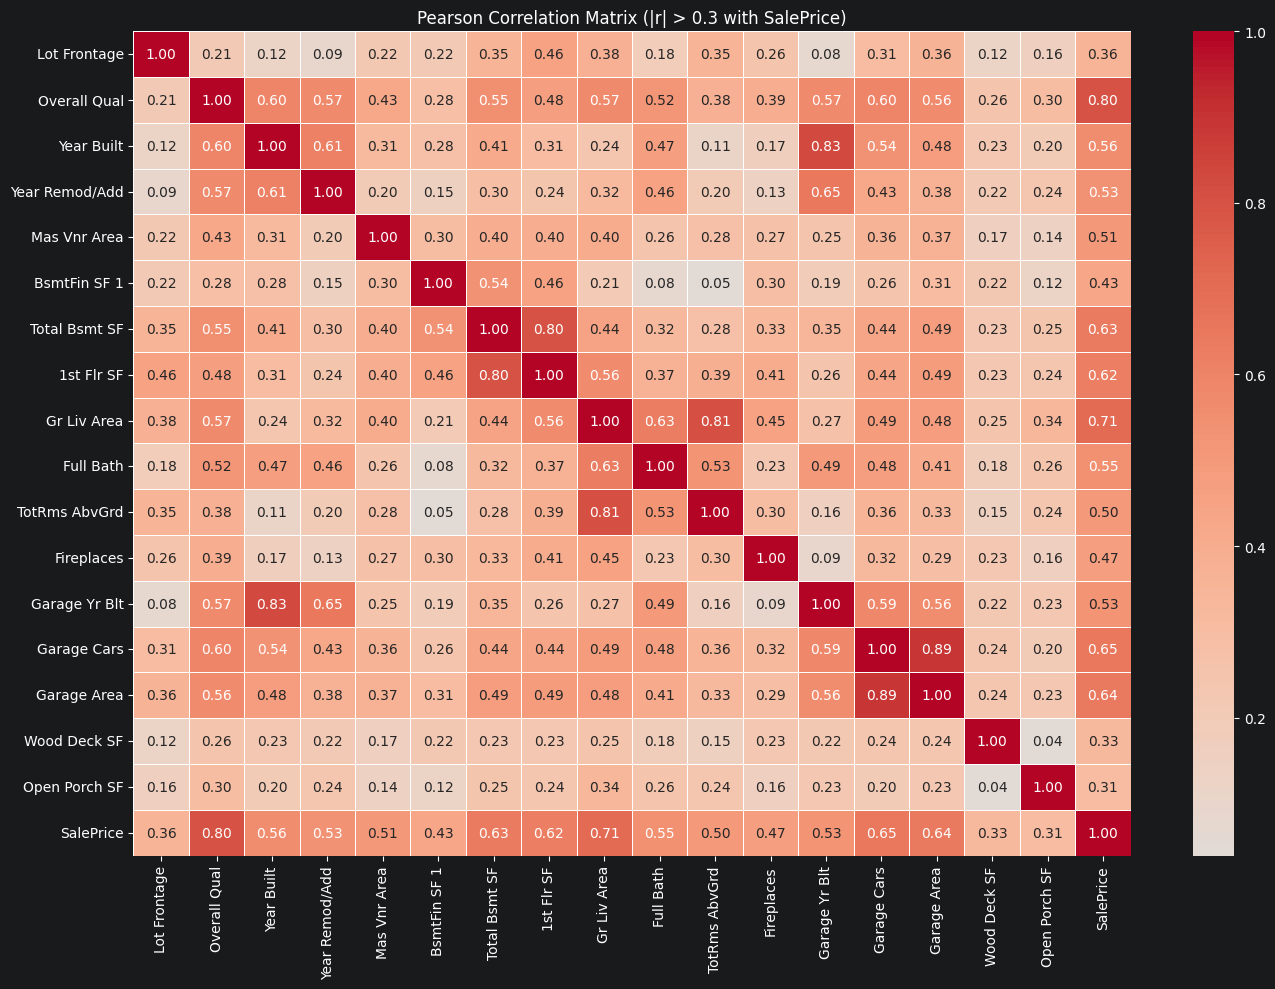

In [17]:
high_corr_cols = corr_pearson.index[corr_pearson['SalePrice'].abs() > 0.3].tolist()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_pearson.loc[high_corr_cols, high_corr_cols],
    cmap="coolwarm", center=0, annot=True, fmt=".2f", linewidths=0.5
)
plt.title("Pearson Correlation Matrix (|r| > 0.3 with SalePrice)")
plt.tight_layout()
plt.show()

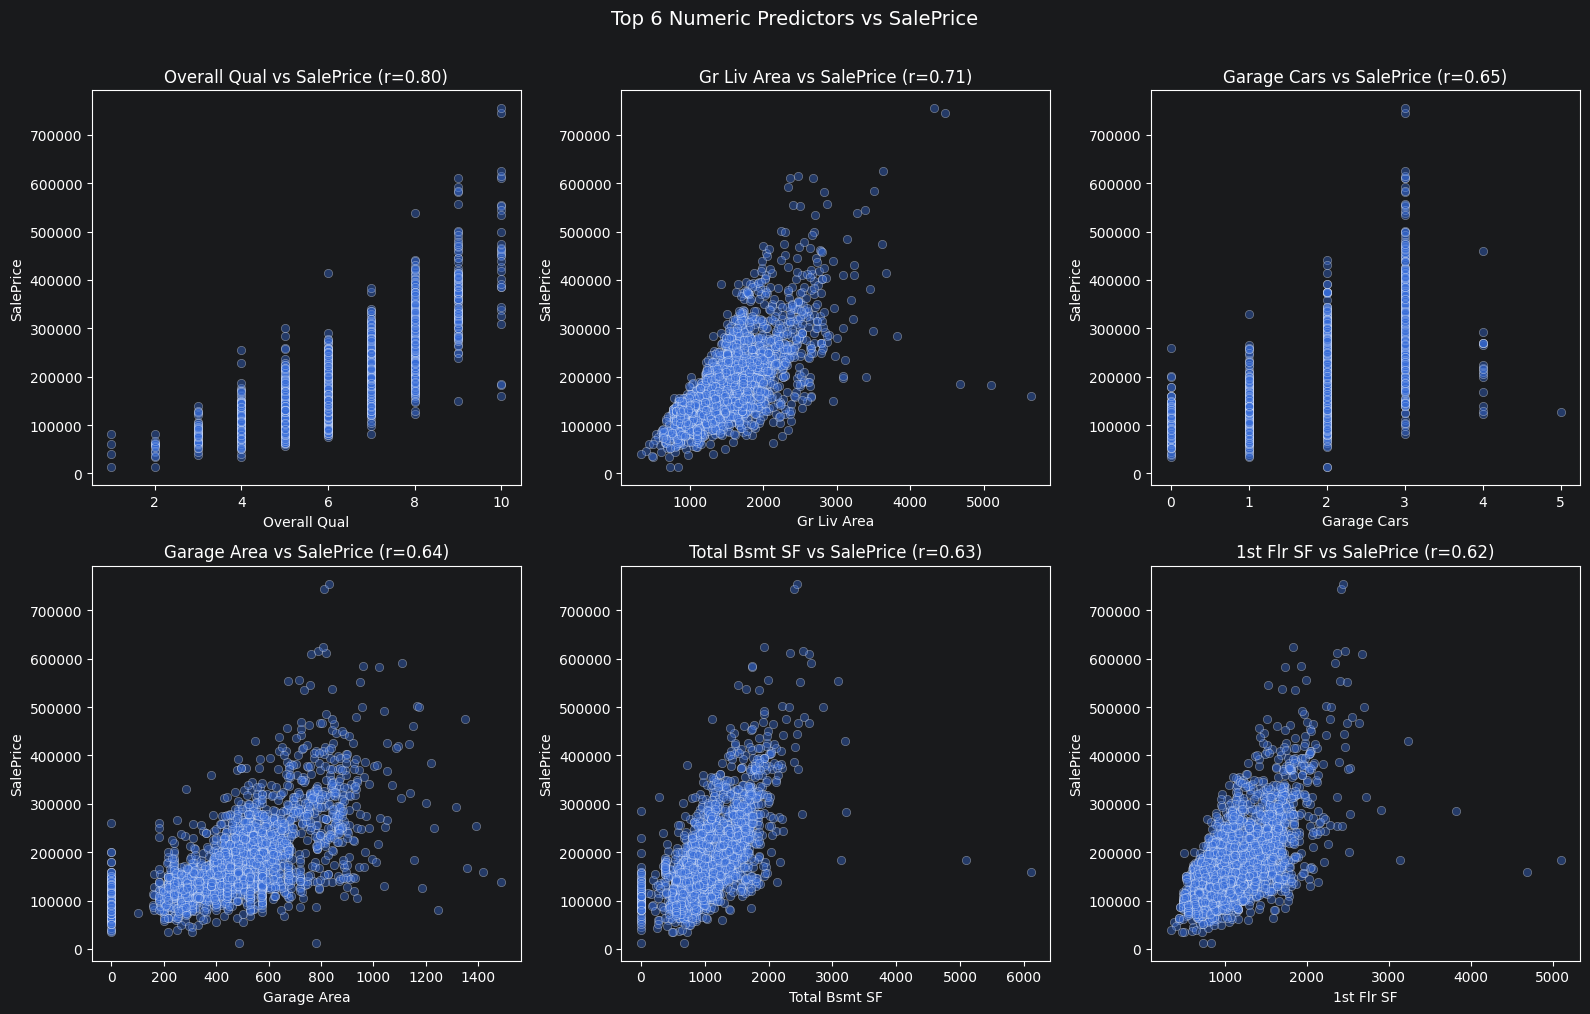

In [18]:
top_predictors = corr_target_pearson.drop('SalePrice').abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(top_predictors):
    sns.scatterplot(data=df, x=col, y='SalePrice', alpha=0.4, ax=axes[i])
    axes[i].set_title(f"{col} vs SalePrice (r={corr_target_pearson[col]:.2f})")

plt.suptitle("Top 6 Numeric Predictors vs SalePrice", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [19]:
corr_spearman = df.corr(method='spearman', numeric_only=True)
corr_target_spearman = corr_spearman['SalePrice'].sort_values(ascending=False)

comparison = pd.DataFrame({
    'Pearson': corr_target_pearson,
    'Spearman': corr_target_spearman
}).dropna().sort_values('Spearman', ascending=False)

comparison.head(20)

,Pearson,Spearman
SalePrice,1.000000,1.000000
Overall Qual,0.799262,0.808800
Gr Liv Area,0.706780,0.723342
Garage Cars,0.647877,0.701813
Year Built,0.558426,0.680822
Garage Area,0.640401,0.660676
Garage Yr Blt,0.526965,0.637674
Full Bath,0.545604,0.634161
Total Bsmt SF,0.632280,0.606184
Year Remod/Add,0.532974,0.601454


## 14. Categorical Predictors vs SalePrice

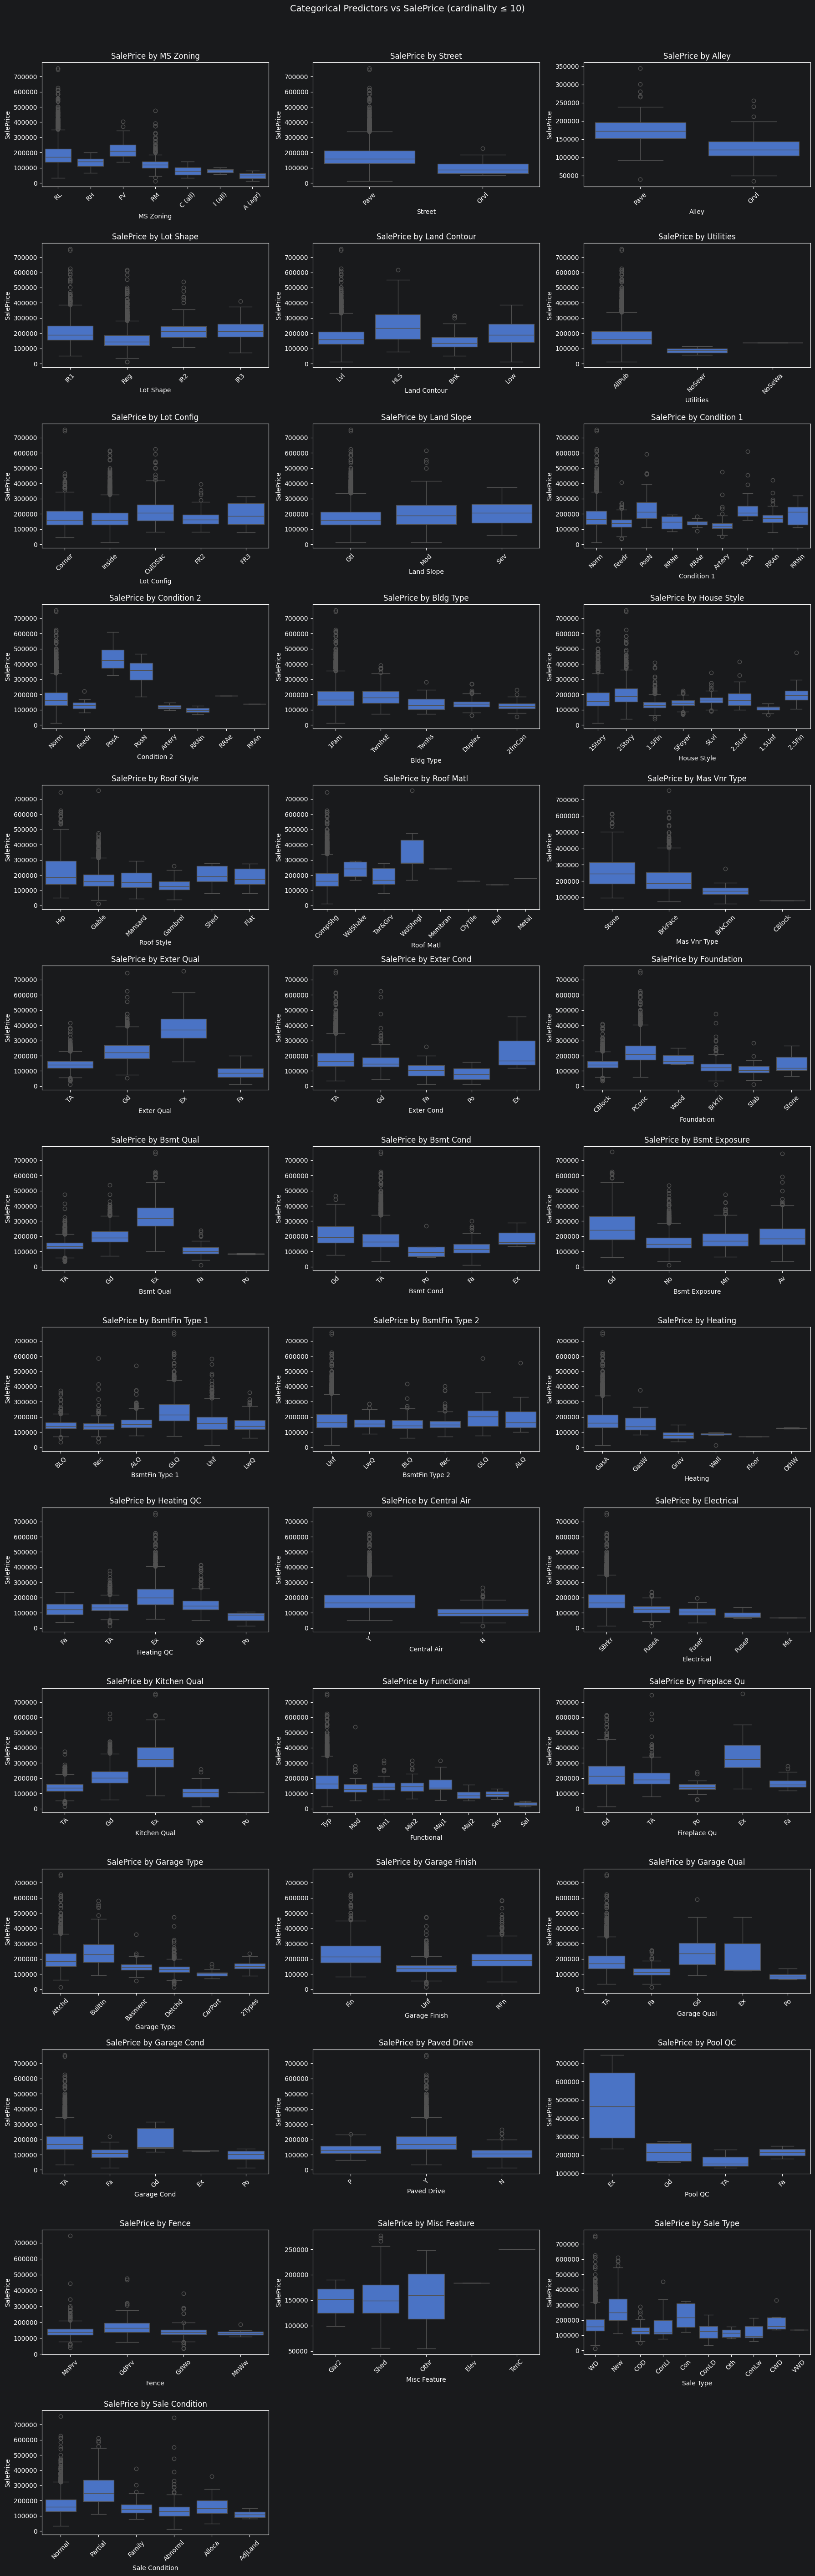

In [20]:
cat_cols_low_card = categorical_report[categorical_report['cardinality'] <= 10]['variable'].tolist()

n = len(cat_cols_low_card)
ncols = 3
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols_low_card):
    sns.boxplot(data=df, x=col, y='SalePrice', ax=axes[i])
    axes[i].set_title(f"SalePrice by {col}")
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Categorical Predictors vs SalePrice (cardinality ≤ 10)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 15. Multicollinearity (VIF)

In [21]:
vif_candidates = corr_target_pearson.drop('SalePrice').abs().sort_values(ascending=False).head(10).index.tolist()

X_vif = df[vif_candidates].dropna()
X_vif = sm.add_constant(X_vif)

vif_df = pd.DataFrame({
    'variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

vif_df[vif_df['variable'] != 'const'].sort_values('VIF', ascending=False)

,variable,VIF
3,Garage Cars,4.214013
10,Garage Yr Blt,4.195869
4,Garage Area,4.103045
7,Year Built,3.950127
6,1st Flr SF,3.412438
5,Total Bsmt SF,3.303768
1,Overall Qual,2.597191
2,Gr Liv Area,2.583254
8,Full Bath,2.186414
9,Year Remod/Add,2.025649


## 16. Cramér's V — Categorical Association

In [22]:
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    n = table.sum().sum()
    k = min(table.shape)
    if k <= 1:
        return np.nan
    chi2, _, _, _ = chi2_contingency(table)
    return np.sqrt(chi2 / (n * (k - 1)))


cat_cols_for_cramers = categorical_report[categorical_report['cardinality'] <= 15]['variable'].tolist()

pairs = [
    {'var1': col1, 'var2': col2, 'cramers_v': round(cramers_v(df[col1], df[col2]), 3)}
    for i, col1 in enumerate(cat_cols_for_cramers)
    for col2 in cat_cols_for_cramers[i+1:]
    if not np.isnan(cramers_v(df[col1], df[col2]))
]

pd.DataFrame(pairs).sort_values('cramers_v', ascending=False).head(20)

,var1,var2,cramers_v
1,MS Zoning,Alley,0.798
465,Mas Vnr Type,Pool QC,0.764
534,Foundation,Pool QC,0.677
87,Alley,Bsmt Qual,0.658
628,BsmtFin Type 2,Pool QC,0.636
79,Alley,Bldg Type,0.634
706,Functional,Pool QC,0.624
489,Exter Qual,Pool QC,0.622
84,Alley,Exter Qual,0.613
387,House Style,Pool QC,0.602
